<a href="https://colab.research.google.com/github/avashachhami/IPPR/blob/main/lab6/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Number of connected components: 111


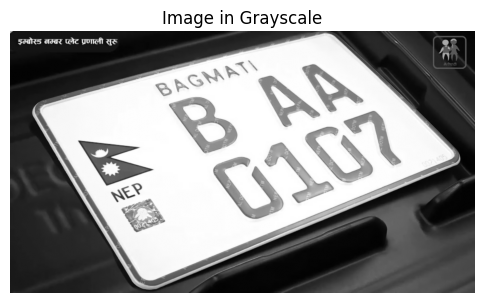

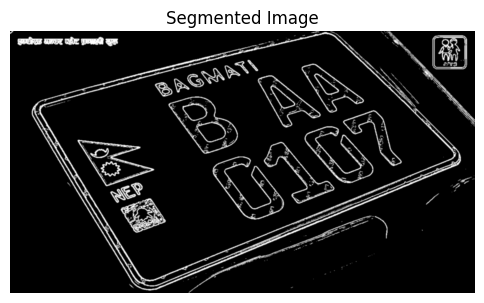

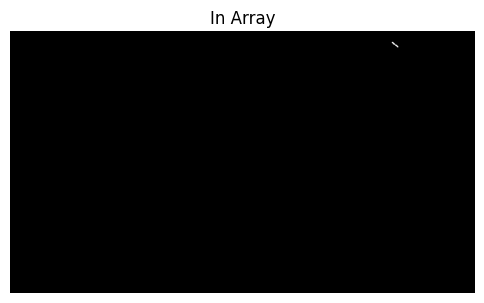

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from scipy.ndimage import median_filter
from skimage.feature import canny
from skimage.measure import label

# Read image
im = cv2.imread('number_plate.jpg')

# Convert to grayscale
im1 = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

# Median filtering to remove noise
im1 = median_filter(im1, size=3)

# Finding edges (MATLAB uses Sobel edge detector)
# OpenCV Sobel
sobelx = cv2.Sobel(im1, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(im1, cv2.CV_64F, 0, 1, ksize=3)
BW = np.sqrt(sobelx**2 + sobely**2)
BW = (BW > 100).astype(np.uint8)  # Adjust threshold if needed

# Image size
imx, imy = BW.shape

# Mask
msk = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0]
], dtype=np.uint8)

# Smoothing image
B = convolve2d(BW.astype(float), msk.astype(float), mode='same')

# Connected component labeling (8-connectivity)
L = label(B > 0, connectivity=2)

mx = L.max()
print("Number of connected components:", mx)

# MATLAB uses component number 17
component_number = 17

# Find pixels belonging to component 17
r, c = np.where(L == component_number)

# Store extracted image in array
n1 = np.zeros((imx, imy), dtype=np.uint8)
n1[r, c] = 255

# Display results
plt.figure(figsize=(6,6))
plt.imshow(im1, cmap='gray')
plt.title('Image in Grayscale')
plt.axis('off')

plt.figure(figsize=(6,6))
plt.imshow(B, cmap='gray')
plt.title('Segmented Image')
plt.axis('off')

plt.figure(figsize=(6,6))
plt.imshow(n1, cmap='gray')
plt.title('In Array')
plt.axis('off')

plt.show()

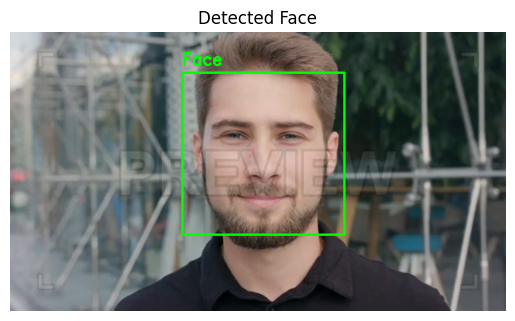

In [2]:
import cv2
import matplotlib.pyplot as plt

# -----------------------------
# Load Haar Cascade Face Detector
# -----------------------------
face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# -----------------------------
# Open the video file
# -----------------------------
video = cv2.VideoCapture('video.mp4')

# Read the first frame
ret, frame = video.read()

if not ret:
    print("Error: Could not read video.")
    exit()

# -----------------------------
# Convert frame to grayscale
# -----------------------------
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# -----------------------------
# Detect faces
# -----------------------------
faces = face_detector.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

# -----------------------------
# Draw rectangles around faces
# -----------------------------
for (x, y, w, h) in faces:
    cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(frame, "Face", (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7, (0, 255, 0), 2)

# Convert BGR to RGB for displaying with matplotlib
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# -----------------------------
# Display the result
# -----------------------------
plt.imshow(frame_rgb)
plt.title("Detected Face")
plt.axis("off")
plt.show()

# Release the video
video.release()